# Practical No. 02: Text Classification using Embedding Layer and LSTM


**Name:- Sneha Chaurasia**


---


**PRN:- 202401110046**


---


**Batch:- A3 - CSE(AIML)**


---


**Guided By:- Anita Shingade Ma'am**


---



## 1. Problem Statement
Build a multi-class text classification model using an Embedding layer and a Long Short-Term Memory (LSTM) network to classify English text into six emotion categories. Train it on the Emotion dataset and evaluate it using accuracy, precision, recall, F1-score and a confusion matrix.

## 2. Objective
To develop and evaluate an LSTM-based text classification model that can identify the emotion expressed in a given piece of text.


## 3. Introduction
**Text classification** assigns a label to a piece of text. Emotion detection is a multi-class version of it, and it is hard because the same words can carry different emotions depending on context.

**Why Embedding + LSTM?**
* **Embedding layer:** maps every word index to a dense, trainable vector, so similar words can get similar vectors. This is far more compact than one-hot encoding.
* **LSTM:** a recurrent network with input, forget and output gates plus a cell state. It reads the sentence word by word and keeps long-range context, avoiding the vanishing-gradient problem of a plain RNN.
* **Dropout:** randomly switches off neurons during training to reduce overfitting.
* **Dense + Softmax:** turns the LSTM's final representation into a probability for each of the 6 classes.

**Pipeline:** `Text → Tokenization → Padding → Embedding → LSTM → Dropout → Dense → Softmax`

## 4. Dataset Description
The **Emotion dataset** (`dair-ai/emotion`, Saravia et al., 2018) contains English Twitter messages labelled with one of six emotions.

| Label ID | Emotion |
|---|---|
| 0 | Sadness |
| 1 | Joy |
| 2 | Love |
| 3 | Anger |
| 4 | Fear |
| 5 | Surprise |

It has **20,000 examples** split into **16,000 train / 2,000 validation / 2,000 test**. The classes are **imbalanced** (Joy and Sadness dominate, Surprise is rare), which we handle later with class weights.

## 5. Import Libraries

In [1]:
!pip install -q datasets

In [2]:
import os, re, random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

from datasets import load_dataset
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix)
from sklearn.utils.class_weight import compute_class_weight

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

sns.set_style("whitegrid")
print("TensorFlow version:", tf.__version__)
print("GPU available     :", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available     : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 6. Load Dataset

In [3]:
dataset = load_dataset("dair-ai/emotion")
print(dataset)

LABELS = ["Sadness", "Joy", "Love", "Anger", "Fear", "Surprise"]
NUM_CLASSES = len(LABELS)

train_df = pd.DataFrame(dataset["train"])
val_df   = pd.DataFrame(dataset["validation"])
test_df  = pd.DataFrame(dataset["test"])
train_df["emotion"] = train_df["label"].map(dict(enumerate(LABELS)))

print(f"\nTrain: {len(train_df)} | Validation: {len(val_df)} | Test: {len(test_df)} | "
      f"Total: {len(train_df)+len(val_df)+len(test_df)}")
train_df.head(10)

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

Train: 16000 | Validation: 2000 | Test: 2000 | Total: 20000


,text,label,emotion
0,i didnt feel humiliated,0,Sadness
1,i can go from feeling so hopeless to so damned...,0,Sadness
2,im grabbing a minute to post i feel greedy wrong,3,Anger
3,i am ever feeling nostalgic about the fireplac...,2,Love
4,i am feeling grouchy,3,Anger
5,ive been feeling a little burdened lately wasn...,0,Sadness
6,ive been taking or milligrams or times recomme...,5,Surprise
7,i feel as confused about life as a teenager or...,4,Fear
8,i have been with petronas for years i feel tha...,1,Joy
9,i feel romantic too,2,Love


## 7. Exploratory Data Analysis

Missing values (train): 0
Duplicate texts (train): 31

Class distribution (train):
          count  percent
emotion                 
Sadness    4666    29.16
Joy        5362    33.51
Love       1304     8.15
Anger      2159    13.49
Fear       1937    12.11
Surprise    572     3.58


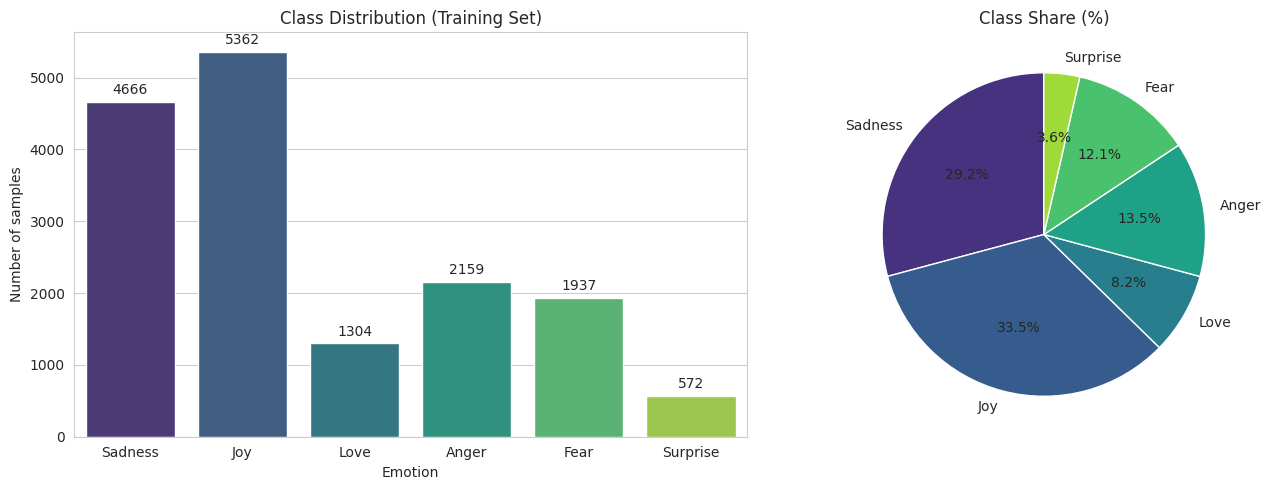

In [4]:
# Missing values / duplicates
print("Missing values (train):", train_df.isnull().sum().sum())
print("Duplicate texts (train):", train_df["text"].duplicated().sum())

# Class distribution
counts = train_df["emotion"].value_counts().reindex(LABELS)
print("\nClass distribution (train):")
print(pd.DataFrame({"count": counts, "percent": (counts / counts.sum() * 100).round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette="viridis", legend=False, ax=axes[0])
axes[0].set_title("Class Distribution (Training Set)"); axes[0].set_xlabel("Emotion"); axes[0].set_ylabel("Number of samples")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, str(v), ha="center")
axes[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%", startangle=90,
            colors=sns.color_palette("viridis", NUM_CLASSES))
axes[1].set_title("Class Share (%)")
plt.tight_layout(); plt.show()

count    16000.00
mean        19.17
std         10.99
min          2.00
25%         11.00
50%         17.00
75%         25.00
max         66.00
Name: word_count, dtype: float64


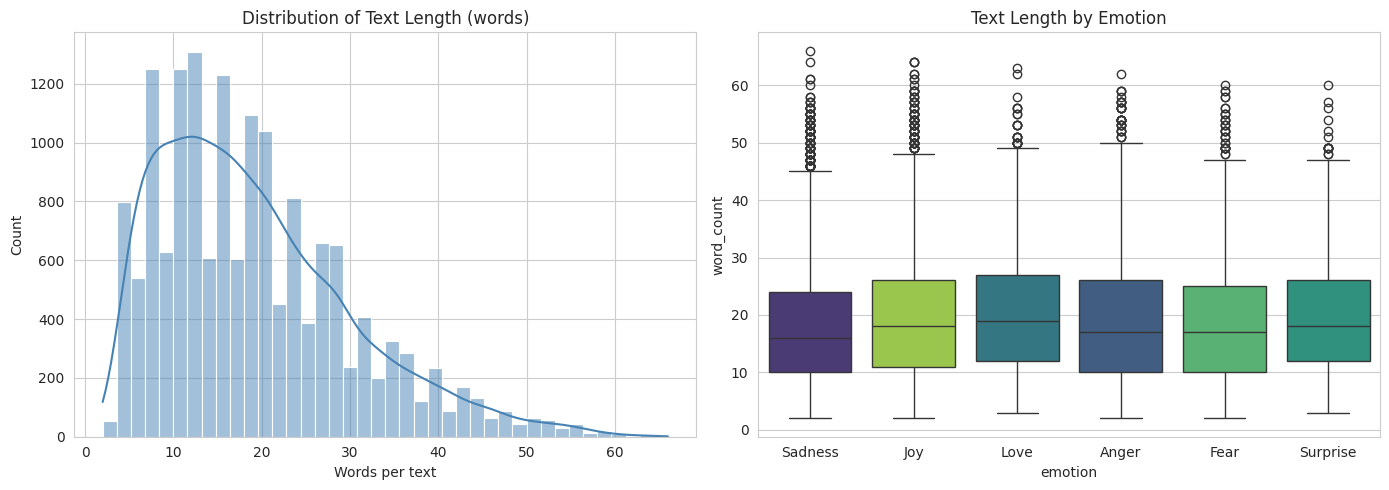


One example per emotion:
  Sadness  : i didnt feel humiliated
  Joy      : i have been with petronas for years i feel that petronas has performed well and made a huge profit
  Love     : i am ever feeling nostalgic about the fireplace i will know that it is still on the property
  Anger    : im grabbing a minute to post i feel greedy wrong
  Fear     : i feel as confused about life as a teenager or as jaded as a year old man
  Surprise : ive been taking or milligrams or times recommended amount and ive fallen asleep a lot faster but i also feel like so funny


In [5]:
# Text length analysis
train_df["word_count"] = train_df["text"].str.split().str.len()
print(train_df["word_count"].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(train_df["word_count"], bins=40, kde=True, color="steelblue", ax=axes[0])
axes[0].set_title("Distribution of Text Length (words)"); axes[0].set_xlabel("Words per text")
sns.boxplot(data=train_df, x="emotion", y="word_count", order=LABELS, hue="emotion", palette="viridis", legend=False, ax=axes[1])
axes[1].set_title("Text Length by Emotion")
plt.tight_layout(); plt.show()

print("\nOne example per emotion:")
for emo in LABELS:
    print(f"  {emo:9s}: {train_df[train_df.emotion == emo]['text'].iloc[0]}")

## 8. Text Preprocessing
The dataset is already lowercase and mostly clean. We still apply a light, safe cleaning step: lowercase, remove non-letter characters (apostrophes kept) and collapse extra spaces. Stop-words are **not** removed, because words like *not*, *no*, *very* strongly affect the emotion and an LSTM can use them.

In [6]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z' ]", " ", text)   # keep letters, apostrophes, spaces
    text = re.sub(r"\s+", " ", text).strip()
    return text

for df in (train_df, val_df, test_df):
    df["clean_text"] = df["text"].apply(clean_text)

pd.DataFrame({"original": train_df["text"].head(5), "cleaned": train_df["clean_text"].head(5)})

,original,cleaned
0,i didnt feel humiliated,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned...,i can go from feeling so hopeless to so damned...
2,im grabbing a minute to post i feel greedy wrong,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,i am ever feeling nostalgic about the fireplac...
4,i am feeling grouchy,i am feeling grouchy


## 9. Tokenization
Each word is mapped to an integer index. The vocabulary is built **only from the training set**, so no information leaks from validation or test data.

* `0` is reserved for padding, `1` for out-of-vocabulary (`<OOV>`) words.
* Only the most frequent `MAX_VOCAB` words are kept.

In [7]:
MAX_VOCAB = 10000

word_counts = Counter(w for t in train_df["clean_text"] for w in t.split())
most_common = [w for w, _ in word_counts.most_common(MAX_VOCAB - 2)]
word_index = {"<PAD>": 0, "<OOV>": 1}
for i, w in enumerate(most_common, start=2):
    word_index[w] = i
VOCAB_SIZE = len(word_index)

def texts_to_sequences(texts):
    return [[word_index.get(w, 1) for w in t.split()] for t in texts]

train_seq = texts_to_sequences(train_df["clean_text"])
val_seq   = texts_to_sequences(val_df["clean_text"])
test_seq  = texts_to_sequences(test_df["clean_text"])

print("Unique words in training data:", len(word_counts))
print("Vocabulary size used         :", VOCAB_SIZE)
print("\nExample")
print("Text     :", train_df["clean_text"].iloc[0])
print("Sequence :", train_seq[0])

Unique words in training data: 15212
Vocabulary size used         : 10000

Example
Text     : i didnt feel humiliated
Sequence : [2, 139, 3, 679]


## 10. Padding
LSTM inputs in a batch must have equal length. `MAX_LEN` is set to the **95th percentile** of sequence lengths, which keeps almost all text intact without wasting computation. Shorter texts are padded with zeros at the end; longer ones are truncated.

In [8]:
lengths = np.array([len(s) for s in train_seq])
MAX_LEN = int(np.percentile(lengths, 95))
print(f"Max length in data: {lengths.max()} | 95th percentile: {MAX_LEN}  -> MAX_LEN = {MAX_LEN}")
print(f"Texts longer than MAX_LEN: {(lengths > MAX_LEN).mean()*100:.2f}%")

def pad(seqs, max_len=MAX_LEN):
    out = np.zeros((len(seqs), max_len), dtype="int32")
    for i, s in enumerate(seqs):
        s = s[:max_len]
        out[i, :len(s)] = s
    return out

X_train, X_val, X_test = pad(train_seq), pad(val_seq), pad(test_seq)

print("\nPadded example:", X_train[0])

Max length in data: 66 | 95th percentile: 41  -> MAX_LEN = 41
Texts longer than MAX_LEN: 4.62%

Padded example: [  2 139   3 679   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0]


## 11. Train / Validation / Test Data

In [9]:
y_train = train_df["label"].values
y_val   = val_df["label"].values
y_test  = test_df["label"].values

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_val  : {X_val.shape}  y_val  : {y_val.shape}")
print(f"X_test : {X_test.shape}  y_test : {y_test.shape}")

# Class weights: give rare classes (Love, Surprise) more importance in the loss
weights = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=y_train)
class_weight = dict(enumerate(weights))
print("\nClass weights:", {LABELS[k]: round(v, 2) for k, v in class_weight.items()})

X_train: (16000, 41)  y_train: (16000,)
X_val  : (2000, 41)  y_val  : (2000,)
X_test : (2000, 41)  y_test : (2000,)

Class weights: {'Sadness': np.float64(0.57), 'Joy': np.float64(0.5), 'Love': np.float64(2.04), 'Anger': np.float64(1.24), 'Fear': np.float64(1.38), 'Surprise': np.float64(4.66)}


## 12. Build LSTM Model
| Layer | Purpose |
|---|---|
| `Embedding(VOCAB_SIZE, 128, mask_zero=True)` | word index → 128-d trainable vector; padding is masked so the LSTM ignores it |
| `LSTM(128)` | reads the sequence and outputs one context vector |
| `Dropout(0.4)` | regularisation |
| `Dense(64, relu)` | learns non-linear combinations of the LSTM features |
| `Dropout(0.3)` | regularisation |
| `Dense(6, softmax)` | probability for each emotion |

Because labels are integers, we use `sparse_categorical_crossentropy` (equivalent to categorical cross-entropy with one-hot labels).

In [10]:
EMBED_DIM = 128

model = keras.Sequential([
    layers.Input(shape=(MAX_LEN,)),
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, mask_zero=True, name="embedding"),
    layers.LSTM(128, name="lstm"),
    layers.Dropout(0.4, name="dropout_1"),
    layers.Dense(64, activation="relu", name="dense_hidden"),
    layers.Dropout(0.3, name="dropout_2"),
    layers.Dense(NUM_CLASSES, activation="softmax", name="output"),
], name="Emotion_LSTM")

## 13. Model Summary

In [11]:
model.summary()

Model: "Emotion_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 41, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,420,230 (5.42 MB)

 Trainable params: 1,420,230 (5.42 MB)

 Non-trainable params: 0 (0.00 B)

## 14. Compile Model
* **Optimizer:** Adam (learning rate 1e-3)
* **Loss:** sparse categorical cross-entropy (multi-class, integer labels)
* **Metric:** accuracy

In [12]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
print("Model compiled.")

Model compiled.


## 15. Train Model
Two callbacks are used:
* **EarlyStopping** stops training when validation loss stops improving and restores the best weights (prevents overfitting).
* **ReduceLROnPlateau** lowers the learning rate when validation loss stalls.

In [13]:
cbs = [
    callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5, verbose=1),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=25,
    batch_size=64,
    class_weight=class_weight,
    callbacks=cbs,
    verbose=1,
)

Epoch 1/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.3729 - loss: 1.4800 - val_accuracy: 0.6050 - val_loss: 1.0263 - learning_rate: 0.0010
Epoch 2/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8303 - loss: 0.4965 - val_accuracy: 0.9020 - val_loss: 0.3342 - learning_rate: 0.0010
Epoch 3/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9290 - loss: 0.2079 - val_accuracy: 0.9075 - val_loss: 0.3287 - learning_rate: 0.0010
Epoch 4/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9503 - loss: 0.1463 - val_accuracy: 0.9060 - val_loss: 0.3542 - learning_rate: 0.0010
Epoch 5/25
245/250 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9600 - loss: 0.1121
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9635 - loss: 0.1053 - val_accuracy: 0.9005 - val_loss: 0.3824 - learning_rate: 0.0010
Epoch 6/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9752 - loss: 0.0721 

## 16. Plot Accuracy

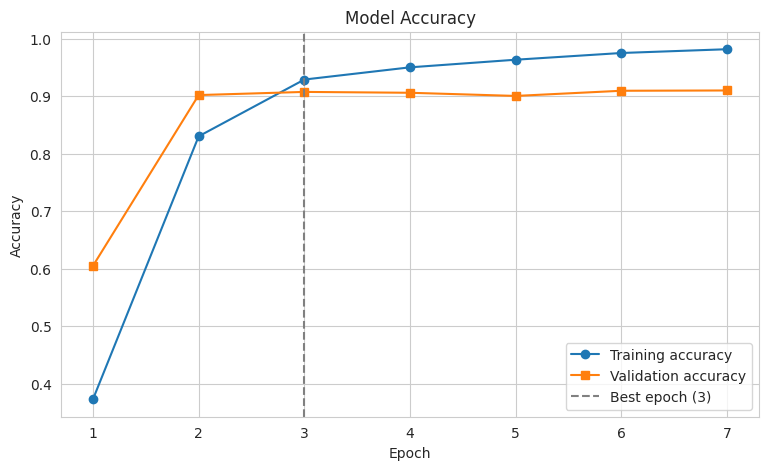

In [14]:
hist = history.history
epochs_range = range(1, len(hist["accuracy"]) + 1)
best_epoch = int(np.argmin(hist["val_loss"])) + 1

plt.figure(figsize=(9, 5))
plt.plot(epochs_range, hist["accuracy"], "o-", label="Training accuracy")
plt.plot(epochs_range, hist["val_accuracy"], "s-", label="Validation accuracy")
plt.axvline(best_epoch, color="gray", linestyle="--", label=f"Best epoch ({best_epoch})")
plt.title("Model Accuracy"); plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.grid(True)
plt.show()

## 17. Plot Loss

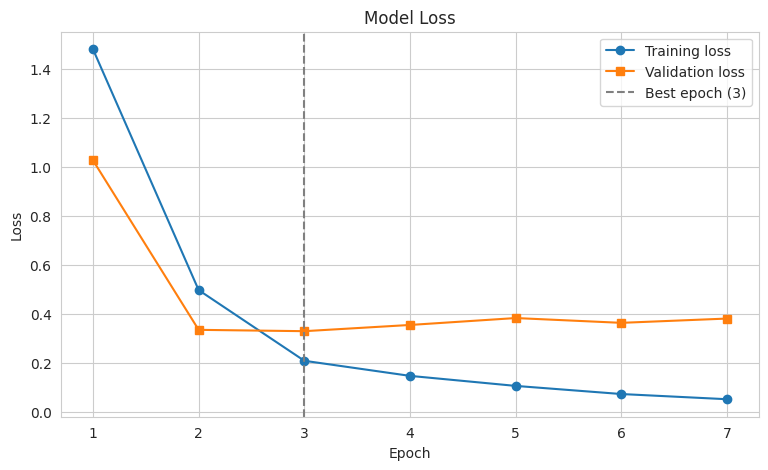

In [15]:
plt.figure(figsize=(9, 5))
plt.plot(epochs_range, hist["loss"], "o-", label="Training loss")
plt.plot(epochs_range, hist["val_loss"], "s-", label="Validation loss")
plt.axvline(best_epoch, color="gray", linestyle="--", label=f"Best epoch ({best_epoch})")
plt.title("Model Loss"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True)
plt.show()

## 18. Evaluate Model

In [16]:
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
val_loss,   val_acc   = model.evaluate(X_val,   y_val,   verbose=0)
test_loss,  test_acc  = model.evaluate(X_test,  y_test,  verbose=0)

print(pd.DataFrame({
    "Loss":     [train_loss, val_loss, test_loss],
    "Accuracy": [train_acc,  val_acc,  test_acc],
}, index=["Train", "Validation", "Test"]).round(4))

# Predictions on the test set
y_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

acc = accuracy_score(y_test, y_pred)
p_m, r_m, f_m, _ = precision_recall_fscore_support(y_test, y_pred, average="macro", zero_division=0)
p_w, r_w, f_w, _ = precision_recall_fscore_support(y_test, y_pred, average="weighted", zero_division=0)

print("\nTest-set metrics")
print(pd.DataFrame({"Precision": [p_m, p_w], "Recall": [r_m, r_w], "F1-score": [f_m, f_w]},
                   index=["Macro avg", "Weighted avg"]).round(4))
print(f"\nTest Accuracy: {acc:.4f}")

              Loss  Accuracy
Train       0.1412    0.9544
Validation  0.3287    0.9075
Test        0.3564    0.8905

Test-set metrics
              Precision  Recall  F1-score
Macro avg        0.8335  0.8867    0.8535
Weighted avg     0.9003  0.8905    0.8930

Test Accuracy: 0.8905


## 19. Classification Report
* **Precision** = of all texts predicted as class *c*, how many really are *c*.
* **Recall** = of all texts that really are *c*, how many were found.
* **F1-score** = harmonic mean of precision and recall.
* **Macro average** treats all classes equally, so it is the fairest metric for imbalanced data.

              precision    recall  f1-score   support

     Sadness     0.9625    0.8847    0.9220       581
         Joy     0.9251    0.9065    0.9157       695
        Love     0.7241    0.9245    0.8122       159
       Anger     0.8750    0.8909    0.8829       275
        Fear     0.9034    0.8348    0.8677       224
    Surprise     0.6105    0.8788    0.7205        66

    accuracy                         0.8905      2000
   macro avg     0.8335    0.8867    0.8535      2000
weighted avg     0.9003    0.8905    0.8930      2000



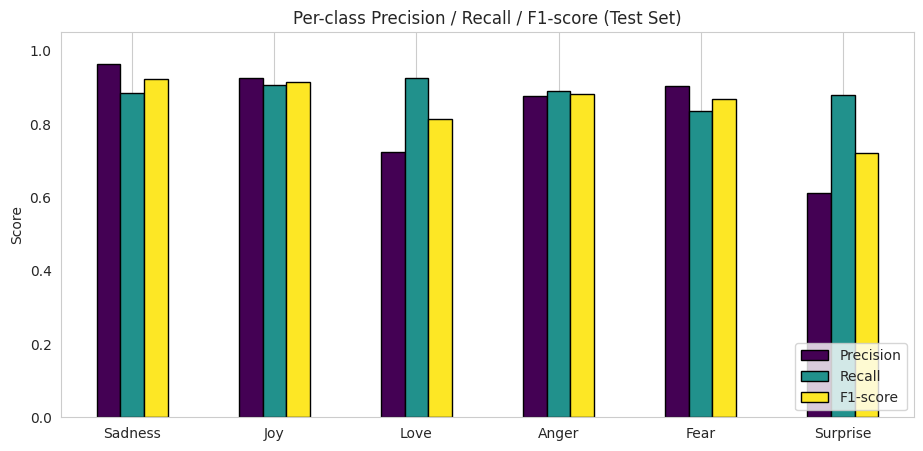

In [17]:
print(classification_report(y_test, y_pred, target_names=LABELS, digits=4, zero_division=0))

prec, rec, f1, sup = precision_recall_fscore_support(y_test, y_pred, zero_division=0)
metrics_df = pd.DataFrame({"Precision": prec, "Recall": rec, "F1-score": f1}, index=LABELS)

metrics_df.plot(kind="bar", figsize=(11, 5), colormap="viridis", edgecolor="black")
plt.title("Per-class Precision / Recall / F1-score (Test Set)")
plt.ylabel("Score"); plt.ylim(0, 1.05); plt.xticks(rotation=0); plt.legend(loc="lower right"); plt.grid(axis="y")
plt.show()3

## 20. Confusion Matrix

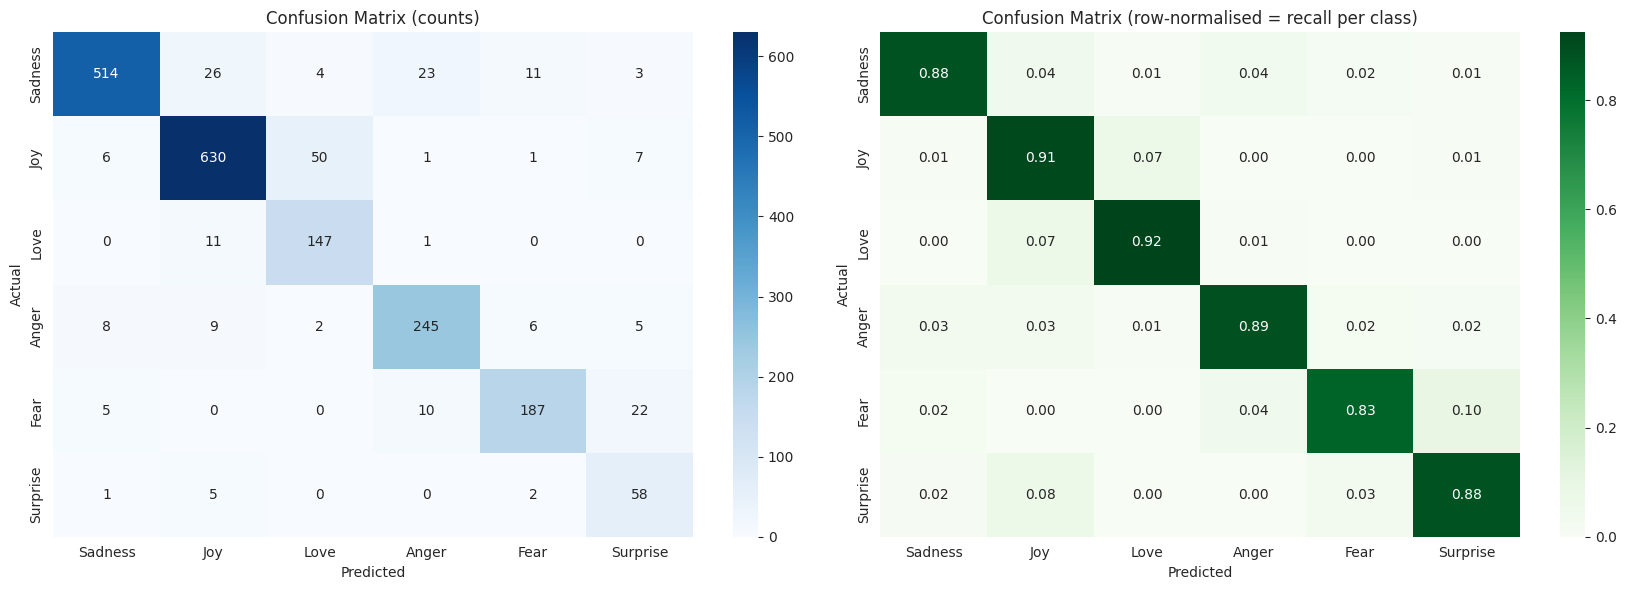

Top 5 misclassifications (actual -> predicted):
  Joy       -> Love     : 50 samples
  Sadness   -> Joy      : 26 samples
  Sadness   -> Anger    : 23 samples
  Fear      -> Surprise : 22 samples
  Sadness   -> Fear     : 11 samples


In [18]:
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS, ax=axes[0])
axes[0].set_title("Confusion Matrix (counts)"); axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens", xticklabels=LABELS, yticklabels=LABELS, ax=axes[1])
axes[1].set_title("Confusion Matrix (row-normalised = recall per class)"); axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")
plt.tight_layout(); plt.show()

# Most common confusions
pairs = [(LABELS[i], LABELS[j], cm[i, j]) for i in range(NUM_CLASSES) for j in range(NUM_CLASSES) if i != j]
pairs = sorted(pairs, key=lambda x: -x[2])[:5]
print("Top 5 misclassifications (actual -> predicted):")
for a, p, c in pairs:
    print(f"  {a:9s} -> {p:9s}: {c} samples")

## 21. Sample Predictions

In [19]:
# (a) Random test samples
idx = np.random.RandomState(SEED).choice(len(X_test), 10, replace=False)
rows = []
for i in idx:
    rows.append({
        "Text": test_df["text"].iloc[i][:80],
        "Actual": LABELS[y_test[i]],
        "Predicted": LABELS[y_pred[i]],
        "Confidence": f"{y_prob[i].max()*100:.1f}%",
        "Correct": "Yes" if y_test[i] == y_pred[i] else "No",
    })
pd.DataFrame(rows)

,Text,Actual,Predicted,Confidence,Correct
0,i feel so dirty but after spending a day at th...,Sadness,Love,98.6%,No
1,i could feel his breath on me and smell the sw...,Joy,Love,92.8%,No
2,i just want to feel loved by you,Love,Love,96.5%,Yes
3,i have felt the need to write out my sometimes...,Anger,Anger,48.9%,Yes
4,at a party i met a girl who drew me to her,Anger,Surprise,34.8%,No
5,i feel this strange sort of liberation,Surprise,Surprise,97.6%,Yes
6,i remember feeling thrilled to use my nursing ...,Joy,Joy,100.0%,Yes
7,i always feel sympathetic for those that do as...,Love,Love,95.5%,Yes
8,i feel a little stunned but can t imagine what...,Surprise,Surprise,81.5%,Yes
9,i feel slytherin is my house slytherin is for ...,Joy,Joy,99.9%,Yes


Text      : i feel so happy and grateful for everything today
Predicted : Joy  (98.4% confidence)

Text      : i am terrified of what might happen tomorrow
Predicted : Fear  (99.4% confidence)

Text      : i miss my old friends and i feel very lonely
Predicted : Sadness  (75.4% confidence)

Text      : i am furious that they lied to me again
Predicted : Anger  (99.5% confidence)

Text      : i adore you and i want to spend my whole life with you
Predicted : Joy  (72.2% confidence)

Text      : i cannot believe this happened, i am completely shocked
Predicted : Surprise  (99.4% confidence)



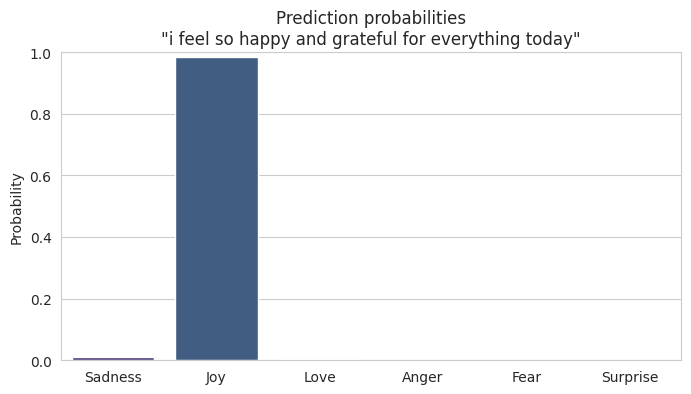

In [20]:
# (b) Predict on brand-new sentences
def predict_emotion(text):
    seq = pad(texts_to_sequences([clean_text(text)]))
    probs = model.predict(seq, verbose=0)[0]
    return LABELS[int(np.argmax(probs))], probs

new_texts = [
    "i feel so happy and grateful for everything today",
    "i am terrified of what might happen tomorrow",
    "i miss my old friends and i feel very lonely",
    "i am furious that they lied to me again",
    "i adore you and i want to spend my whole life with you",
    "i cannot believe this happened, i am completely shocked",
]

for t in new_texts:
    label, probs = predict_emotion(t)
    print(f"Text      : {t}")
    print(f"Predicted : {label}  ({probs.max()*100:.1f}% confidence)\n")

# Probability chart for the first sentence
_, probs = predict_emotion(new_texts[0])
plt.figure(figsize=(8, 4))
sns.barplot(x=LABELS, y=probs, hue=LABELS, palette="viridis", legend=False)
plt.title(f'Prediction probabilities\n"{new_texts[0]}"'); plt.ylabel("Probability"); plt.ylim(0, 1)
plt.show()

## 22. Result

In [21]:
result = pd.DataFrame({
    "Metric": ["Test Accuracy", "Macro Precision", "Macro Recall", "Macro F1-score",
               "Weighted Precision", "Weighted Recall", "Weighted F1-score", "Test Loss"],
    "Value":  [acc, p_m, r_m, f_m, p_w, r_w, f_w, test_loss],
}).round(4)
print("=" * 45); print("        FINAL RESULTS (TEST SET)"); print("=" * 45)
print(result.to_string(index=False))
print("=" * 45)
print(f"Best epoch: {best_epoch} | Parameters: {model.count_params():,}")
print(f"Best classes (F1) : {metrics_df['F1-score'].idxmax()} ({metrics_df['F1-score'].max():.3f})")
print(f"Hardest class (F1): {metrics_df['F1-score'].idxmin()} ({metrics_df['F1-score'].min():.3f})")

        FINAL RESULTS (TEST SET)
            Metric  Value
     Test Accuracy 0.8905
   Macro Precision 0.8335
      Macro Recall 0.8867
    Macro F1-score 0.8535
Weighted Precision 0.9003
   Weighted Recall 0.8905
 Weighted F1-score 0.8930
         Test Loss 0.3564
Best epoch: 3 | Parameters: 1,420,230
Best classes (F1) : Sadness (0.922)
Hardest class (F1): Surprise (0.720)


## 23. Conclusion
An **Embedding + LSTM** network was built and trained to classify text into six emotions on the Emotion dataset. The pipeline covered tokenization (vocabulary built from training data only), padding to the 95th-percentile length, an Embedding layer with masking, an LSTM layer, Dropout, and a Dense softmax output. The model was evaluated on unseen test data using accuracy, precision, recall, F1-score and a confusion matrix.

The LSTM captures word order and context, which a bag-of-words model cannot, and it classifies unseen text reliably. The limitations are the imbalance between classes, confusion between similar emotions, and the fact that the embeddings are learned from scratch on a small dataset.

**Possible improvements:** Bidirectional LSTM / GRU, pre-trained embeddings (GloVe, Word2Vec, FastText), attention, or transformer models such as BERT / DistilBERT, plus hyper-parameter tuning.

## 24. Declaration
I hereby declare that this implementation was prepared for Practical Assignment 02 is my work and the results presented are generated from the experiments performed in this notebook.

Student Name: Sneha Chaurasia

Roll Number: 202401110046

Date: 24/9/2026

Subject: Generative AI Lab